# CSCI 611 Assignment 2
## CNN on CIFAR-10

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler

train_on_gpu = torch.cuda.is_available()
print('Training on', 'GPU' if train_on_gpu else 'CPU')

Training on CPU


## 1. Data Loading

In [2]:
num_workers = 0
batch_size = 20
valid_size = 0.2

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10('data', train=True, download=True, transform=transform_train)
valid_data = datasets.CIFAR10('data', train=True, download=True, transform=transform)
test_data  = datasets.CIFAR10('data', train=False, download=True, transform=transform)

num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=batch_size, num_workers=num_workers)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## 2. Sample Training Images

In [3]:
def imshow(img):
    if hasattr(img, 'numpy'):
        img = img.numpy()
    img = np.clip(img / 2 + 0.5, 0, 1)
    plt.imshow(np.transpose(img, (1, 2, 0)))

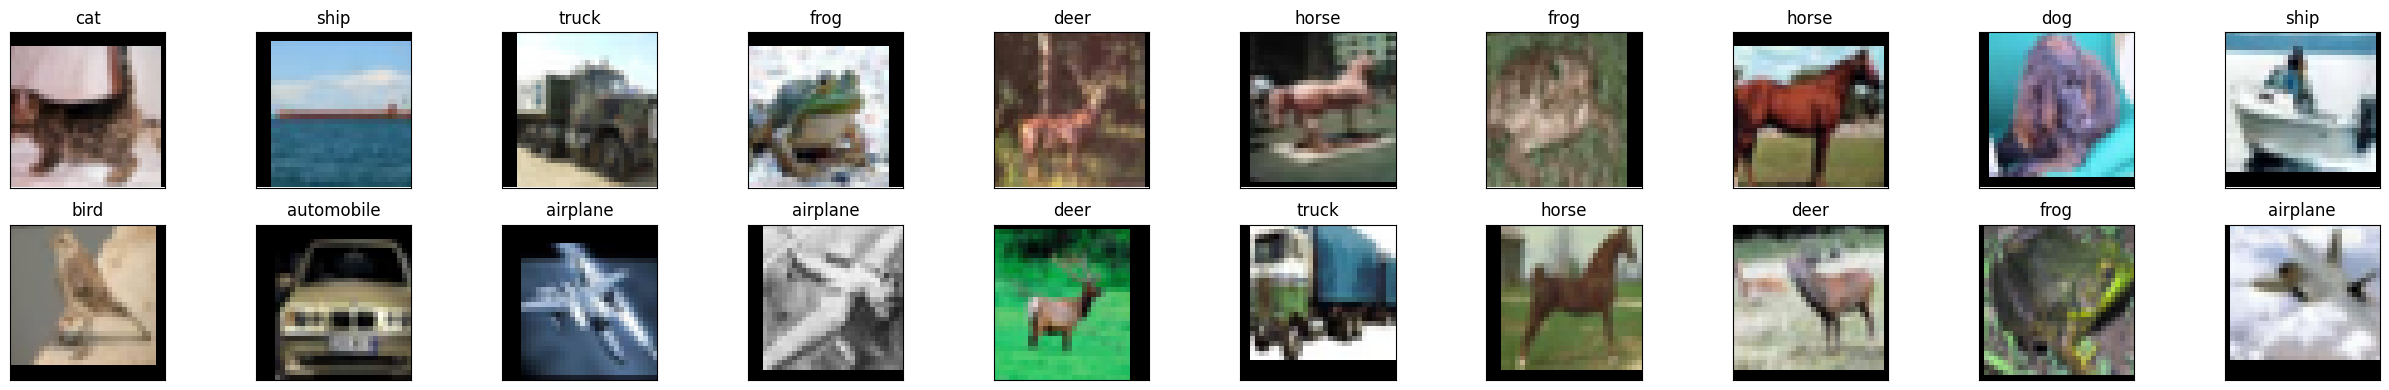

In [4]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])
plt.tight_layout()
plt.show()

### RGB Channel View

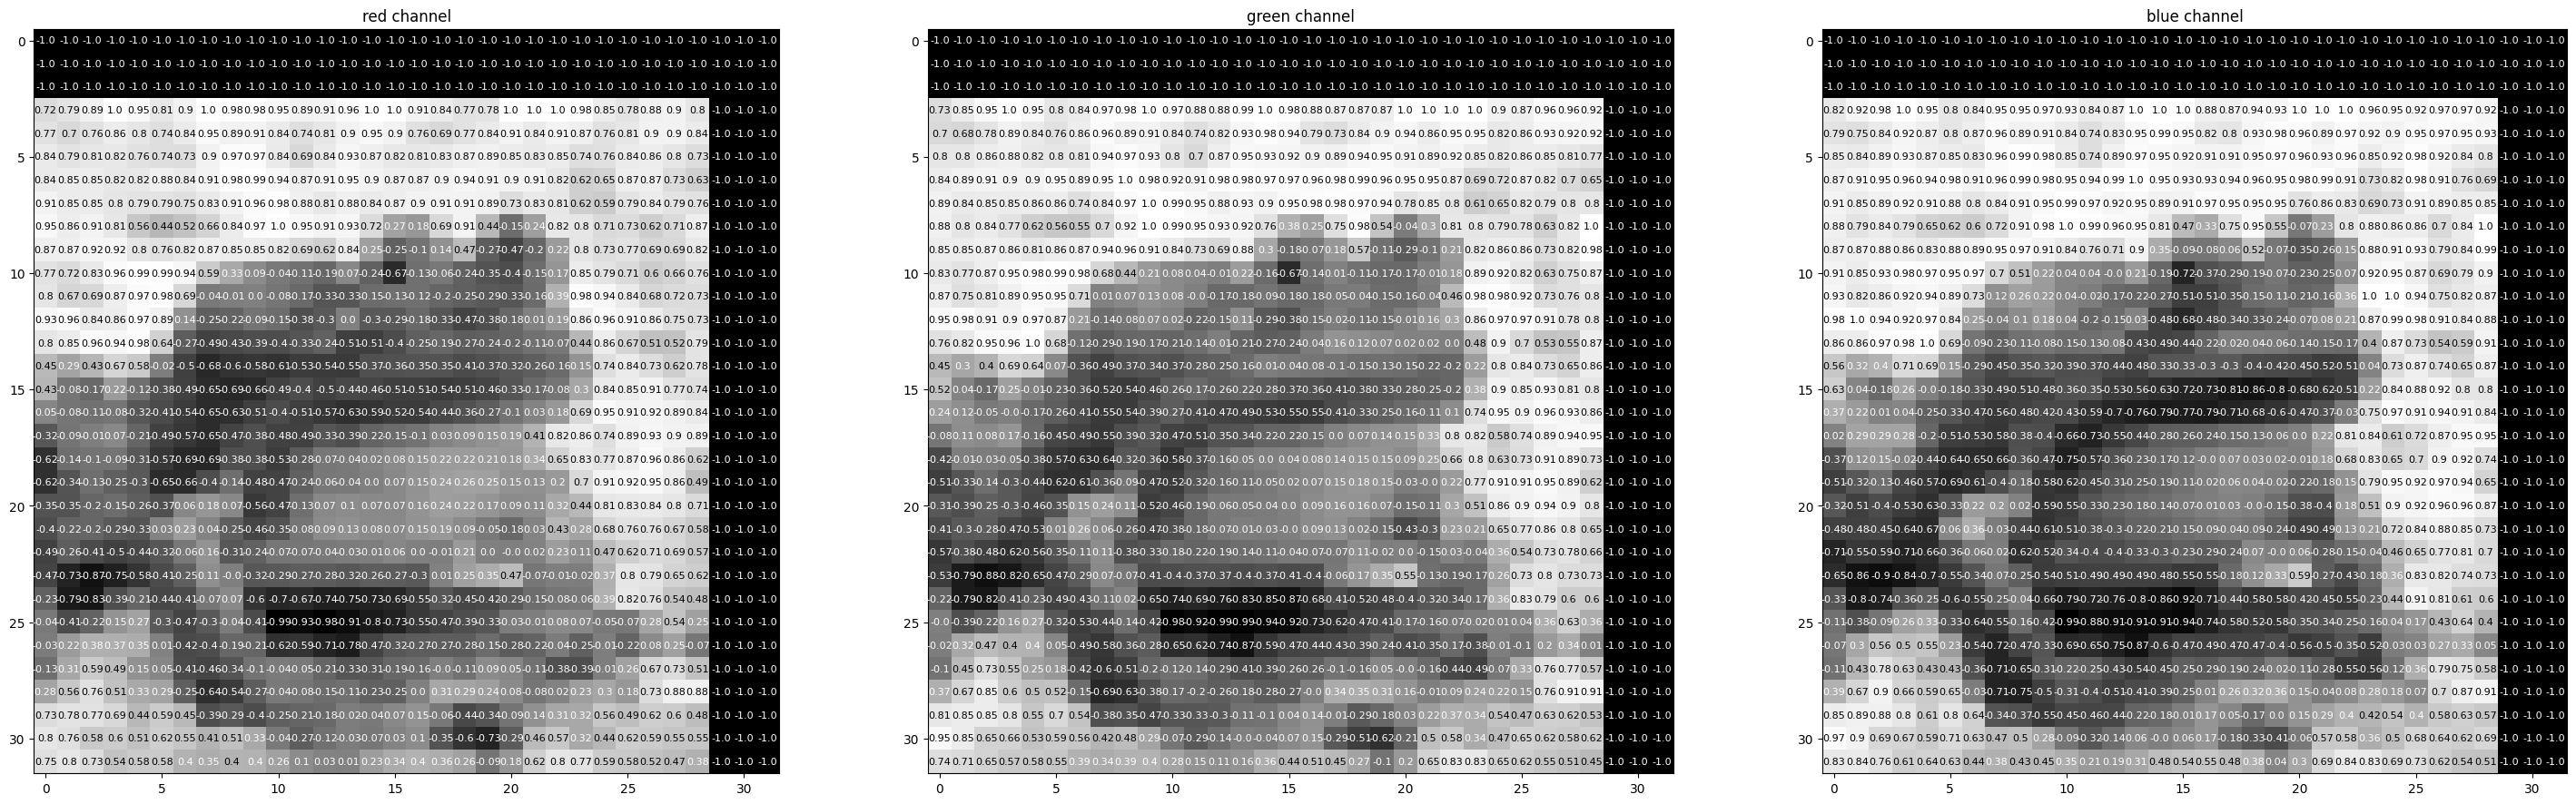

In [5]:
rgb_img = np.squeeze(images[3])
channels = ['red channel', 'green channel', 'blue channel']

fig = plt.figure(figsize=(36, 36))
for idx in np.arange(rgb_img.shape[0]):
    ax = fig.add_subplot(1, 3, idx + 1)
    img = rgb_img[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(channels[idx])
    width, height = img.shape
    thresh = img.max() / 2.5
    for x in range(width):
        for y in range(height):
            val = round(img[x][y], 2) if img[x][y] != 0 else 0
            ax.annotate(str(val), xy=(y, x), horizontalalignment='center',
                        verticalalignment='center', size=8,
                        color='white' if img[x][y] < thresh else 'black')

## 3. Model Architecture

In [6]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

model = Net()
print(model)
if train_on_gpu:
    model.cuda()

Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)


## 4. Loss Function and Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 5. Training

**Setup:** Loss = CrossEntropyLoss | Optimizer = Adam | LR = 0.001 | Batch size = 20 | Epochs = 15 | Dropout = 0.25 | Augmentation = RandomHorizontalFlip + RandomCrop

In [8]:
n_epochs = 15
train_losses, valid_losses = [], []
valid_loss_min = np.inf

for epoch in range(1, n_epochs + 1):
    train_loss, valid_loss = 0.0, 0.0

    model.train()
    for data, target in train_loader:
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        optimizer.zero_grad()
        loss = criterion(model(data), target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)

    model.eval()
    with torch.no_grad():
        for data, target in valid_loader:
            if train_on_gpu:
                data, target = data.cuda(), target.cuda()
            loss = criterion(model(data), target)
            valid_loss += loss.item() * data.size(0)

    train_loss /= len(train_loader.sampler)
    valid_loss /= len(valid_loader.sampler)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(epoch, train_loss, valid_loss))

    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(valid_loss_min, valid_loss))
        torch.save(model.state_dict(), 'model_trained.pt')
        valid_loss_min = valid_loss

Epoch: 1 	Training Loss: 1.644646 	Validation Loss: 1.342551
Validation loss decreased (inf --> 1.342551).  Saving model ...


Epoch: 2 	Training Loss: 1.322644 	Validation Loss: 1.096070
Validation loss decreased (1.342551 --> 1.096070).  Saving model ...


Epoch: 3 	Training Loss: 1.193929 	Validation Loss: 1.023411
Validation loss decreased (1.096070 --> 1.023411).  Saving model ...


Epoch: 4 	Training Loss: 1.110294 	Validation Loss: 0.927537
Validation loss decreased (1.023411 --> 0.927537).  Saving model ...


Epoch: 5 	Training Loss: 1.049837 	Validation Loss: 0.904419
Validation loss decreased (0.927537 --> 0.904419).  Saving model ...


...

Epoch: 11 	Training Loss: 0.905617 	Validation Loss: 0.788265
Validation loss decreased (0.788462 --> 0.788265).  Saving model ...


Epoch: 12 	Training Loss: 0.895732 	Validation Loss: 0.771489
Validation loss decreased (0.788265 --> 0.771489).  Saving model ...


Epoch: 13 	Training Loss: 0.880557 	Validation Loss: 0.749665
Validation loss decreased (0.771489 --> 0.749665).  Saving model ...


Epoch: 14 	Training Loss: 0.877478 	Validation Loss: 0.732199
Validation loss decreased (0.749665 --> 0.732199).  Saving model ...


Epoch: 15 	Training Loss: 0.865896 	Validation Loss: 0.724778
Validation loss decreased (0.732199 --> 0.724778).  Saving model ...


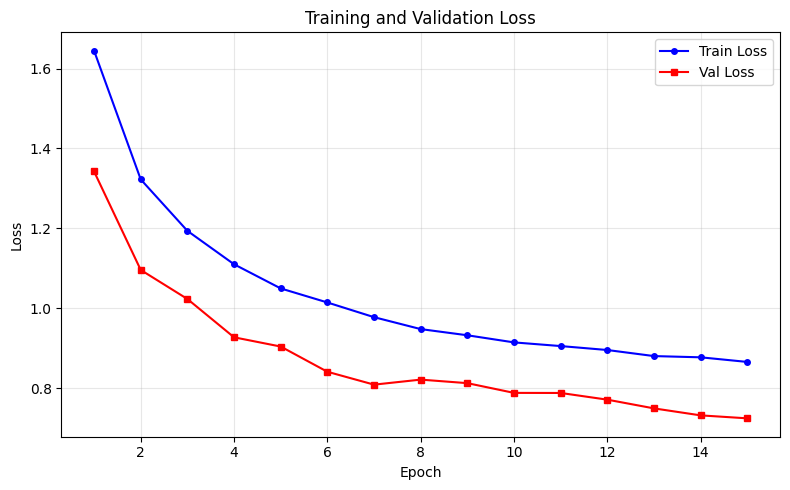

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, 'b-o', label='Train Loss', markersize=4)
plt.plot(range(1, n_epochs + 1), valid_losses, 'r-s', label='Val Loss', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Load Best Model

In [10]:
model.load_state_dict(torch.load('model_trained.pt', weights_only=True))

<All keys matched successfully>

## 7. Test Accuracy

In [11]:
test_loss = 0.0
class_correct = [0.] * 10
class_total   = [0.] * 10

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        if train_on_gpu:
            data, target = data.cuda(), target.cuda()
        output = model(data)
        test_loss += criterion(output, target).item() * data.size(0)
        _, pred = torch.max(output, 1)
        correct = np.squeeze(pred.eq(target.data.view_as(pred)).cpu().numpy())
        for i in range(data.size(0)):
            label = target.data[i].item()
            class_correct[label] += correct[i].item()
            class_total[label]   += 1

print('Test Loss: {:.6f}\n'.format(test_loss / len(test_loader.dataset)))
for i in range(10):
    print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
        classes[i], 100 * class_correct[i] / class_total[i],
        int(class_correct[i]), int(class_total[i])))
print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * sum(class_correct) / sum(class_total),
    int(sum(class_correct)), int(sum(class_total))))

Test Loss: 0.743997

Test Accuracy of airplane: 81% (817/1000)
Test Accuracy of automobile: 91% (912/1000)
Test Accuracy of  bird: 53% (537/1000)
Test Accuracy of   cat: 47% (474/1000)
Test Accuracy of  deer: 69% (696/1000)
Test Accuracy of   dog: 73% (732/1000)
Test Accuracy of  frog: 80% (807/1000)
Test Accuracy of horse: 83% (836/1000)
Test Accuracy of  ship: 80% (800/1000)
Test Accuracy of truck: 84% (844/1000)

Test Accuracy (Overall): 74% (7455/10000)


### Sample Predictions
Green = correct, Red = incorrect

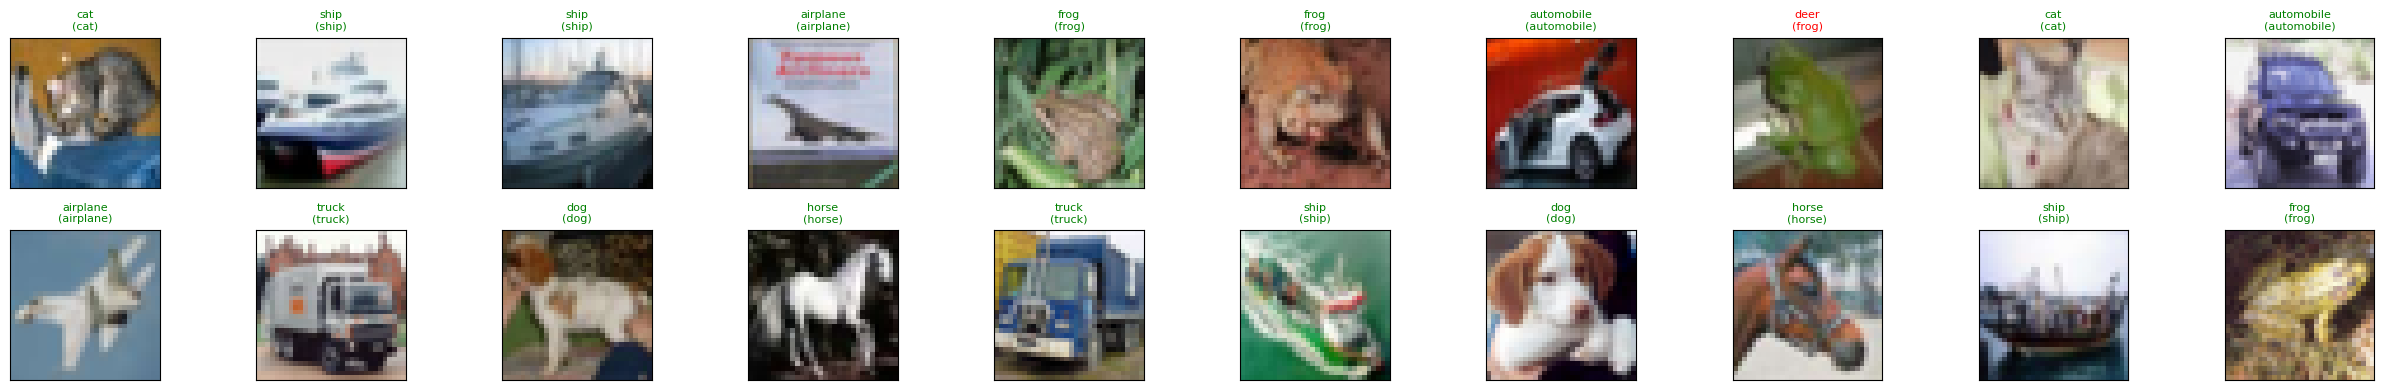

In [12]:
dataiter = iter(test_loader)
images, labels = next(dataiter)
images_np = images.numpy()

if train_on_gpu:
    images = images.cuda()

_, preds_tensor = torch.max(model(images), 1)
preds = preds_tensor.cpu().numpy()

fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    imshow(images_np[idx])
    ax.set_title(f'{classes[preds[idx]]}\n({classes[labels[idx]]})',
                 color='green' if preds[idx] == labels[idx].item() else 'red', fontsize=8)
plt.tight_layout()
plt.show()

## Task 2 Feature Map Visualization
### Part A: First Conv Layer Feature Maps

Three test images from different classes passed through the trained network. Feature maps extracted from conv1 (after ReLU). Each row shows the input image followed by 8 feature maps.

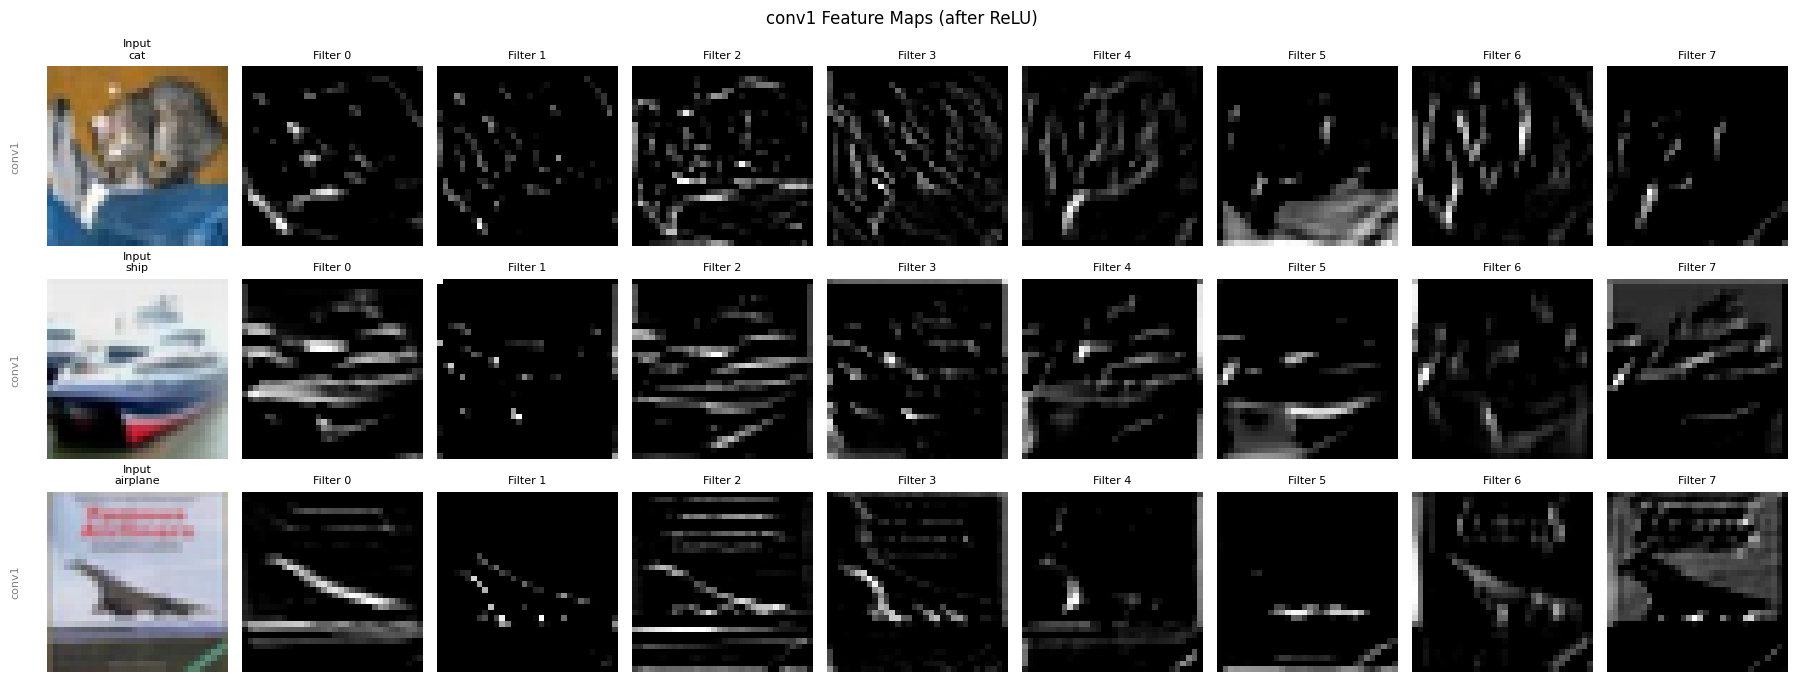

In [13]:
model.eval()
first_conv_out = None

def hook_conv1(module, inp, out):
    global first_conv_out
    first_conv_out = out.detach()

handle = model.conv1.register_forward_hook(hook_conv1)

chosen_classes, chosen_images, chosen_labels = [], [], []
for img, label in test_data:
    if label not in chosen_classes:
        chosen_classes.append(label)
        chosen_images.append(img)
        chosen_labels.append(label)
    if len(chosen_classes) == 3:
        break

n_maps = 8
fig, axes = plt.subplots(3, 1 + n_maps, figsize=(2 * (1 + n_maps), 7))
for row, (img_t, label) in enumerate(zip(chosen_images, chosen_labels)):
    x = img_t.unsqueeze(0).cuda() if train_on_gpu else img_t.unsqueeze(0)
    with torch.no_grad():
        model(x)
    fm = np.maximum(first_conv_out[0].cpu().numpy(), 0)
    img_np = np.clip(img_t.numpy() / 2 + 0.5, 0, 1)
    axes[row, 0].imshow(np.transpose(img_np, (1, 2, 0)))
    axes[row, 0].set_title(f'Input\n{classes[label]}', fontsize=8)
    axes[row, 0].axis('off')
    axes[row, 0].text(-0.15, 0.5, 'conv1', transform=axes[row, 0].transAxes,
                        va='center', ha='right', fontsize=8, rotation=90, color='gray')
    for c in range(n_maps):
        axes[row, c + 1].imshow(fm[c], cmap='gray')
        axes[row, c + 1].set_title(f'Filter {c}', fontsize=8)
        axes[row, c + 1].axis('off')

plt.suptitle('conv1 Feature Maps (after ReLU)', fontsize=12)
plt.tight_layout()
plt.show()
handle.remove()

### Part B: Maximally Activating Images

Layer: conv2 | Filters: 0, 1, 2 | **Activation = mean of 2D feature map after ReLU** | Top 5 test images per filter shown below.

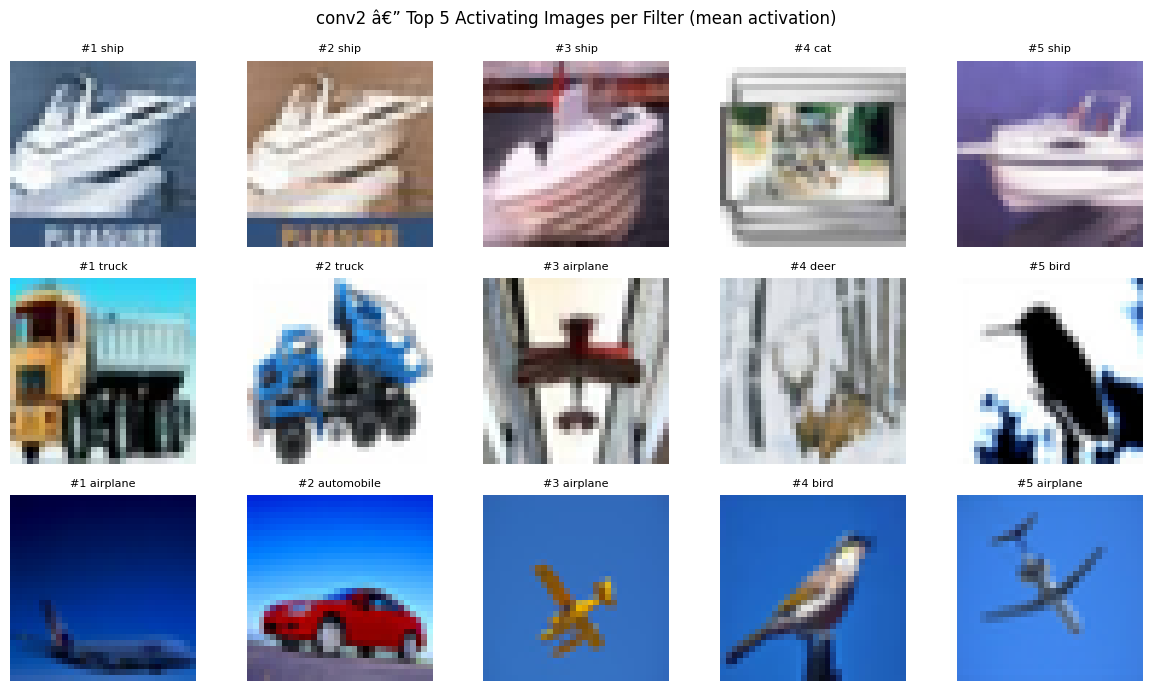

In [14]:
activations_b = None

def hook_conv2(module, inp, out):
    global activations_b
    activations_b = out.detach()

handle_b = model.conv2.register_forward_hook(hook_conv2)

n_filters, top_k = 3, 5
all_act = {f: [] for f in range(n_filters)}
test_images_list = []
idx_global = 0

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        if train_on_gpu:
            data = data.cuda()
        model(data)
        act = np.maximum(activations_b.cpu().numpy(), 0)
        for b in range(data.size(0)):
            for f in range(n_filters):
                all_act[f].append((float(np.mean(act[b, f])), idx_global))
            test_images_list.append((data[b].cpu(), target[b].item()))
            idx_global += 1

handle_b.remove()

top_indices = {}
for f in range(n_filters):
    all_act[f].sort(reverse=True)
    top_indices[f] = [all_act[f][k][1] for k in range(top_k)]

fig, axes = plt.subplots(n_filters, top_k, figsize=(12, 7))
for f in range(n_filters):
    for k in range(top_k):
        img_t, label = test_images_list[top_indices[f][k]]
        img_np = np.clip(img_t.numpy() / 2 + 0.5, 0, 1)
        axes[f, k].imshow(np.transpose(img_np, (1, 2, 0)))
        axes[f, k].set_title(f'#{k+1} {classes[label]}', fontsize=8)
        axes[f, k].axis('off')
    axes[f, 0].set_ylabel(f'Filter {f}', fontsize=10)

plt.suptitle('conv2 â€” Top 5 Activating Images per Filter (mean activation)', fontsize=12)
plt.tight_layout()
plt.show()